### **ElasticNet Regression :**

#### **Project:**

- Medical Insurance Cost Prediction

#### **Problem Statement:**

- Predict insurance charges using demographic and health-related features with balanced regularization.

In [18]:
# Step No 1 : Import required libraries

# Numerical operations
import numpy as np

# Data manipulation and analysis 
import pandas as pd 

# Plotting and visualization
import matplotlib.pyplot as plt

# Advanced visualization library
import seaborn as sns

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Elastic Net Regression model
from sklearn.linear_model import ElasticNet

# evaluation metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error , root_mean_squared_error , r2_score


In [19]:
# Step No 2 : Data Loading and Exploration

# Load the dataset 
df = pd.read_csv("medical_insurance.csv")

In [20]:
# Step No 3 : Understanding the Data

# Display first 5 rows of the dataset 
print("This is the first 5 rows of the dataset : ")
print(df.head())

# Display the shape of the dataset
print("This is shape of the dataset : ")
print(df.shape)

# Display the statistical summary of the dataset 
print("This is the statistical summary of the dataset : ")
print(df.describe())

# Display the information about the dataset 
print("This is the information about the dataset : ")
print(df.info())

This is the first 5 rows of the dataset : 
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
This is shape of the dataset : 
(1338, 7)
This is the statistical summary of the dataset : 
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      

In [21]:
# Step No 4 : Data Cleaning and Preprocessing

# Check for missing values in the dataset 
print("This is the number of missing values in each column : ")
print(df.isnull().sum())

# Check for duplicate values in the dataset 
print("This is the number of duplicate values in the dataset : ")
print(df.duplicated().sum())

# Drop duplicate values from the dataset 
print("This is the dataset after dropping duplicate values : ")
df.drop_duplicates(inplace=True)

This is the number of missing values in each column : 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
This is the number of duplicate values in the dataset : 
1
This is the dataset after dropping duplicate values : 


In [22]:
# Step No 5 : Encoding Categorical Variables 

# Convert smoker column to numerical values 
df["smoker"] = df["smoker"].map({
    "yes":1 , 
    "no": 0
})

# Convert region column to numerical values using one-hot encoding
df = pd.get_dummies(df, columns=["region"] , drop_first=True)

In [23]:
# Step No 6 : Features and Target Splitting 

# Define input features 
X = df[[
    "age",
    "bmi",
    "children",
    "smoker",
    "region_northwest",
    "region_southeast",
    "region_southwest"
]]

# Define target variable 
y = df["charges"]

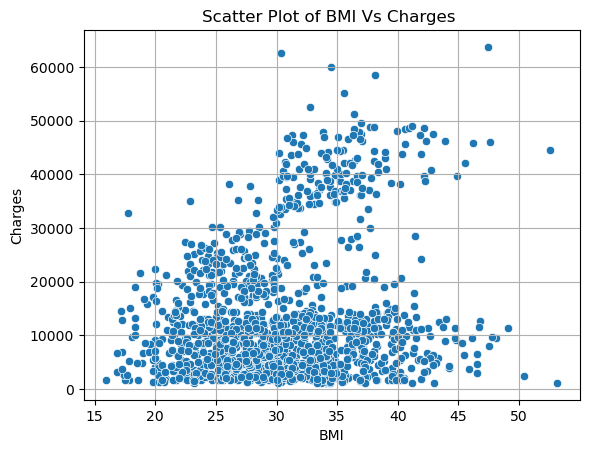

In [24]:
# Step No 7 : Visualization and Correlation Analysis 

# Create a scatter plot 
sns.scatterplot(x = "bmi" , y = "charges" , data = df)

# Set plot title 
plt.title("Scatter Plot of BMI Vs Charges ")

# Set x-axis label 
plt.xlabel("BMI")

# Set y-axis label 
plt.ylabel("Charges")

# Enable grid 
plt.grid()

# Save the plot 
plt.savefig("scatter Plot of BMI Vs Charges(ElasticNet Regression).png")

# Show the plot 
plt.show()

In [25]:
# Step No 8 : Train - Test Split 

X_train , X_test , y_train , y_test = train_test_split(
    X , 
    y ,
    test_size=0.2 ,
    random_state=42)



In [26]:
# Step No 9 : Initialize ElasticNet Regression Model
# Create ElasticNet model 
model = ElasticNet(alpha=0.1 , l1_ratio=0.5 , random_state=42)


In [27]:
# Step No 10 : Model Training
model.fit(X_train , y_train)


,alpha,0.1
,l1_ratio,0.5
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [28]:
# Step No 11 : Prediction 

# Predict insurance charges 
y_pred = model.predict(X_test)

# Display prediction 
print("Predicted Insurance Charges : ")
print(y_pred)

Predicted Insurance Charges : 
[ 9161.94962567  6951.35618633 15144.49005334 27216.86812071
 10417.32537441 14530.08380206 25746.097179    2638.25996839
 11953.1391605  12341.81736355 11308.05255432 28543.50204107
 26465.0104464  18053.04679661 11556.52297753 10666.04402001
  5325.47819532 27655.22061959  4540.14759816  6727.19582341
  5009.9731412  25750.66302052 16086.30251148 26068.52700105
 26381.89970105  6464.28978222 31225.49635228 31975.48245269
 12204.63394519 15084.3463483   7357.93346132 14086.00080166
  2164.63820002 13154.82760045 35153.35092495 13225.96996102
  5977.19994659  5090.1457051  26930.38856415 10398.08543736
  7799.93244637 25605.86745528 30699.09894332 13148.5734569
  8426.54578236  4548.98967359  6970.1015397   9986.00868452
  5295.59900134 10541.83913786  8065.27680582 12792.25342093
 26623.8002325   5109.30625031 12073.60312659 11261.18656969
 11775.97049463  3536.5389932  27091.16801501 10413.27305027
 16831.76401219  9577.07492385 13431.65234111  2709.313

In [29]:
# Step No 12 : Model Evaluation 

# Calculate MAE 
print("Mean Absolute Error : ")
print(mean_absolute_error(y_test,y_pred))

# Calculate MSE
print("mean_squared_error")
print(mean_squared_error(y_test , y_pred))

# Calculate RMSE 
print("Root Mean Squared Error : ")
print(np.sqrt(mean_squared_error(y_test , y_pred)))

# Calculate R2 Score 
print("R2 Score : ")
print(r2_score(y_test , y_pred))

Mean Absolute Error : 
4973.63757141261
mean_squared_error
48001158.156805955
Root Mean Squared Error : 
6928.286812539299
R2 Score : 
0.7387778280554056


In [30]:
# Step No 13 : Feature Importance Analysis 
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Display feature importance 
print("feature_importance")

feature_importance


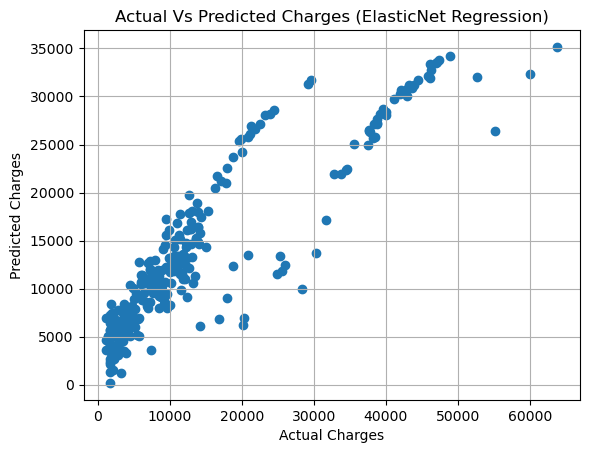

In [31]:
# Step No 14 : Actual Vs Predicted Visualization

# Plot actual Vs predicted values 
plt.scatter(y_test,y_pred)

# Set Plot Title 
plt.title("Actual Vs Predicted Charges (ElasticNet Regression)")

# Set x-axis label 
plt.xlabel("Actual Charges")

# Set y-axis label 
plt.ylabel("Predicted Charges")

# Enable grid
plt.grid()

# Save the Plot 
plt.savefig("Actual Vs Predicted Charges (ElasticNet Regression).png")

# Show the Plot 
plt.show()

In [32]:
# Step No 15 : User input 

# Take age input 
age = int(input("Enter the age : "))

# Take BMI input 
bmi = float(input("Enter the BMI : "))

# Take Childern input
children = int(input("Enter the number of children : "))

# Take smoker input
smoker = int(input("Enter Smoker (1 for Yes or 0 for No ) : "))

# Take region input 
region = input("Enter Region (Northwest / northeast / southwest / southeast) : ")



In [33]:
# Step No 16 : Prediction on User input
#Crate user input dataframe 
user_data = pd.DataFrame({
    "age": [age],
    "bmi": [bmi],
    "children":[children],
    "smoker":[smoker],
    "region_northwest": [1 if region == "nortwest" else 0],
    "region_southeast": [1 if region == "southeast" else 0],
    "region_southwest": [1 if region == "southwest" else 0]
})

# Reindex columns
user_data = user_data.reindex(columns=X.columns , fill_value=0)

# Predict insurance charges 
result = model.predict(user_data)


In [34]:
# Step No 17 : Final Output 
print(f"Predicted Insurance Charges is : ₹{result[0]:.2f} " )

Predicted Insurance Charges is : ₹5182.78 
